In [1]:
# Cài đặt các thư viện cần thiết
!pip install -U ultralytics roboflow opencv-python seaborn matplotlib tqdm > /dev/null
print("Hoàn tất cài đặt các thư viện.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.9 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires num

In [2]:
import os
import yaml
from roboflow import Roboflow

print("Bắt đầu tải dữ liệu từ máy chủ Roboflow...")
rf = Roboflow(api_key="StNCnuoOoDPyDZIEEoWH")
project = rf.workspace("chinhs-workspace-wopqh").project("dentex-3xe7e-20dmh")
version = project.version(1)
dataset = version.download("yolov11")

dataset_location = dataset.location
yaml_path = os.path.join(dataset_location, 'data.yaml')

# Cấu hình lại tệp data.yaml phù hợp với môi trường Kaggle
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

data['path'] = dataset_location
data['train'] = 'train/images'
data['val'] = 'valid/images'
if os.path.exists(os.path.join(dataset_location, 'test', 'images')):
    data['test'] = 'test/images'

with open(yaml_path, 'w') as file:
    yaml.dump(data, file, default_flow_style=False)
    
print("Hoàn tất cấu hình tệp dữ liệu YAML.")



Bắt đầu tải dữ liệu từ máy chủ Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dentex-1 in yolov11:: 100%|██████████| 1415/1415 [00:00<00:00, 8942.76it/s]

Hoàn tất cấu hình tệp dữ liệu YAML.


In [11]:
import cv2
import glob
from tqdm import tqdm

def apply_medical_preprocessing(img_path):
    """
    Tiền xử lý ảnh X-quang y tế: Khử nhiễu, Cân bằng tương phản (CLAHE) và Tăng cường độ nét.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: 
        return
    
    # 1. Khử nhiễu (Gaussian Blur)
    blurred = cv2.GaussianBlur(img, (3, 3), 0)
    
    # 2. Cân bằng biểu đồ thích ứng (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahed = clahe.apply(blurred)
    
    # 3. Làm sắc nét (Unsharp Masking)
    gaussian_3 = cv2.GaussianBlur(clahed, (0, 0), 2.0)
    final_img = cv2.addWeighted(clahed, 1.5, gaussian_3, -0.5, 0)
    
    # Ghi đè tệp ảnh gốc
    cv2.imwrite(img_path, final_img)

print("Đã khởi tạo hàm tiền xử lý dữ liệu ảnh.")


Đã khởi tạo hàm tiền xử lý dữ liệu ảnh.


In [4]:
# Thu thập danh sách ảnh
image_list = glob.glob(os.path.join(dataset_location, '**', 'images', '*.jpg'), recursive=True)

print(f"Bắt đầu tiền xử lý cho {len(image_list)} ảnh X-quang...")

# Áp dụng tiền xử lý cho toàn bộ tập dữ liệu
for img_path in tqdm(image_list):
    apply_medical_preprocessing(img_path)
    
print("Quá trình tiền xử lý ảnh hoàn tất.")


Bắt đầu tiền xử lý cho 705 ảnh X-quang...


100%|██████████| 705/705 [00:04<00:00, 171.32it/s]

Quá trình tiền xử lý ảnh hoàn tất.


In [5]:
from ultralytics import YOLO

print("Khởi chạy quá trình huấn luyện mô hình YOLO11...")

# Khởi tạo mô hình YOLO11 (bản Small)
model = YOLO('yolo11s.pt') 

# Huấn luyện mô hình với 100 epochs
results = model.train(data=yaml_path, epochs=100, imgsz=640, device=0, plots=True)

print("Huấn luyện hoàn tất. Trọng số mô hình được lưu tại: runs/detect/train/weights/best.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Khởi chạy quá trình huấn luyện mô hình YOLO11...
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dentex-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=No

Hiển thị kết quả đánh giá mô hình:


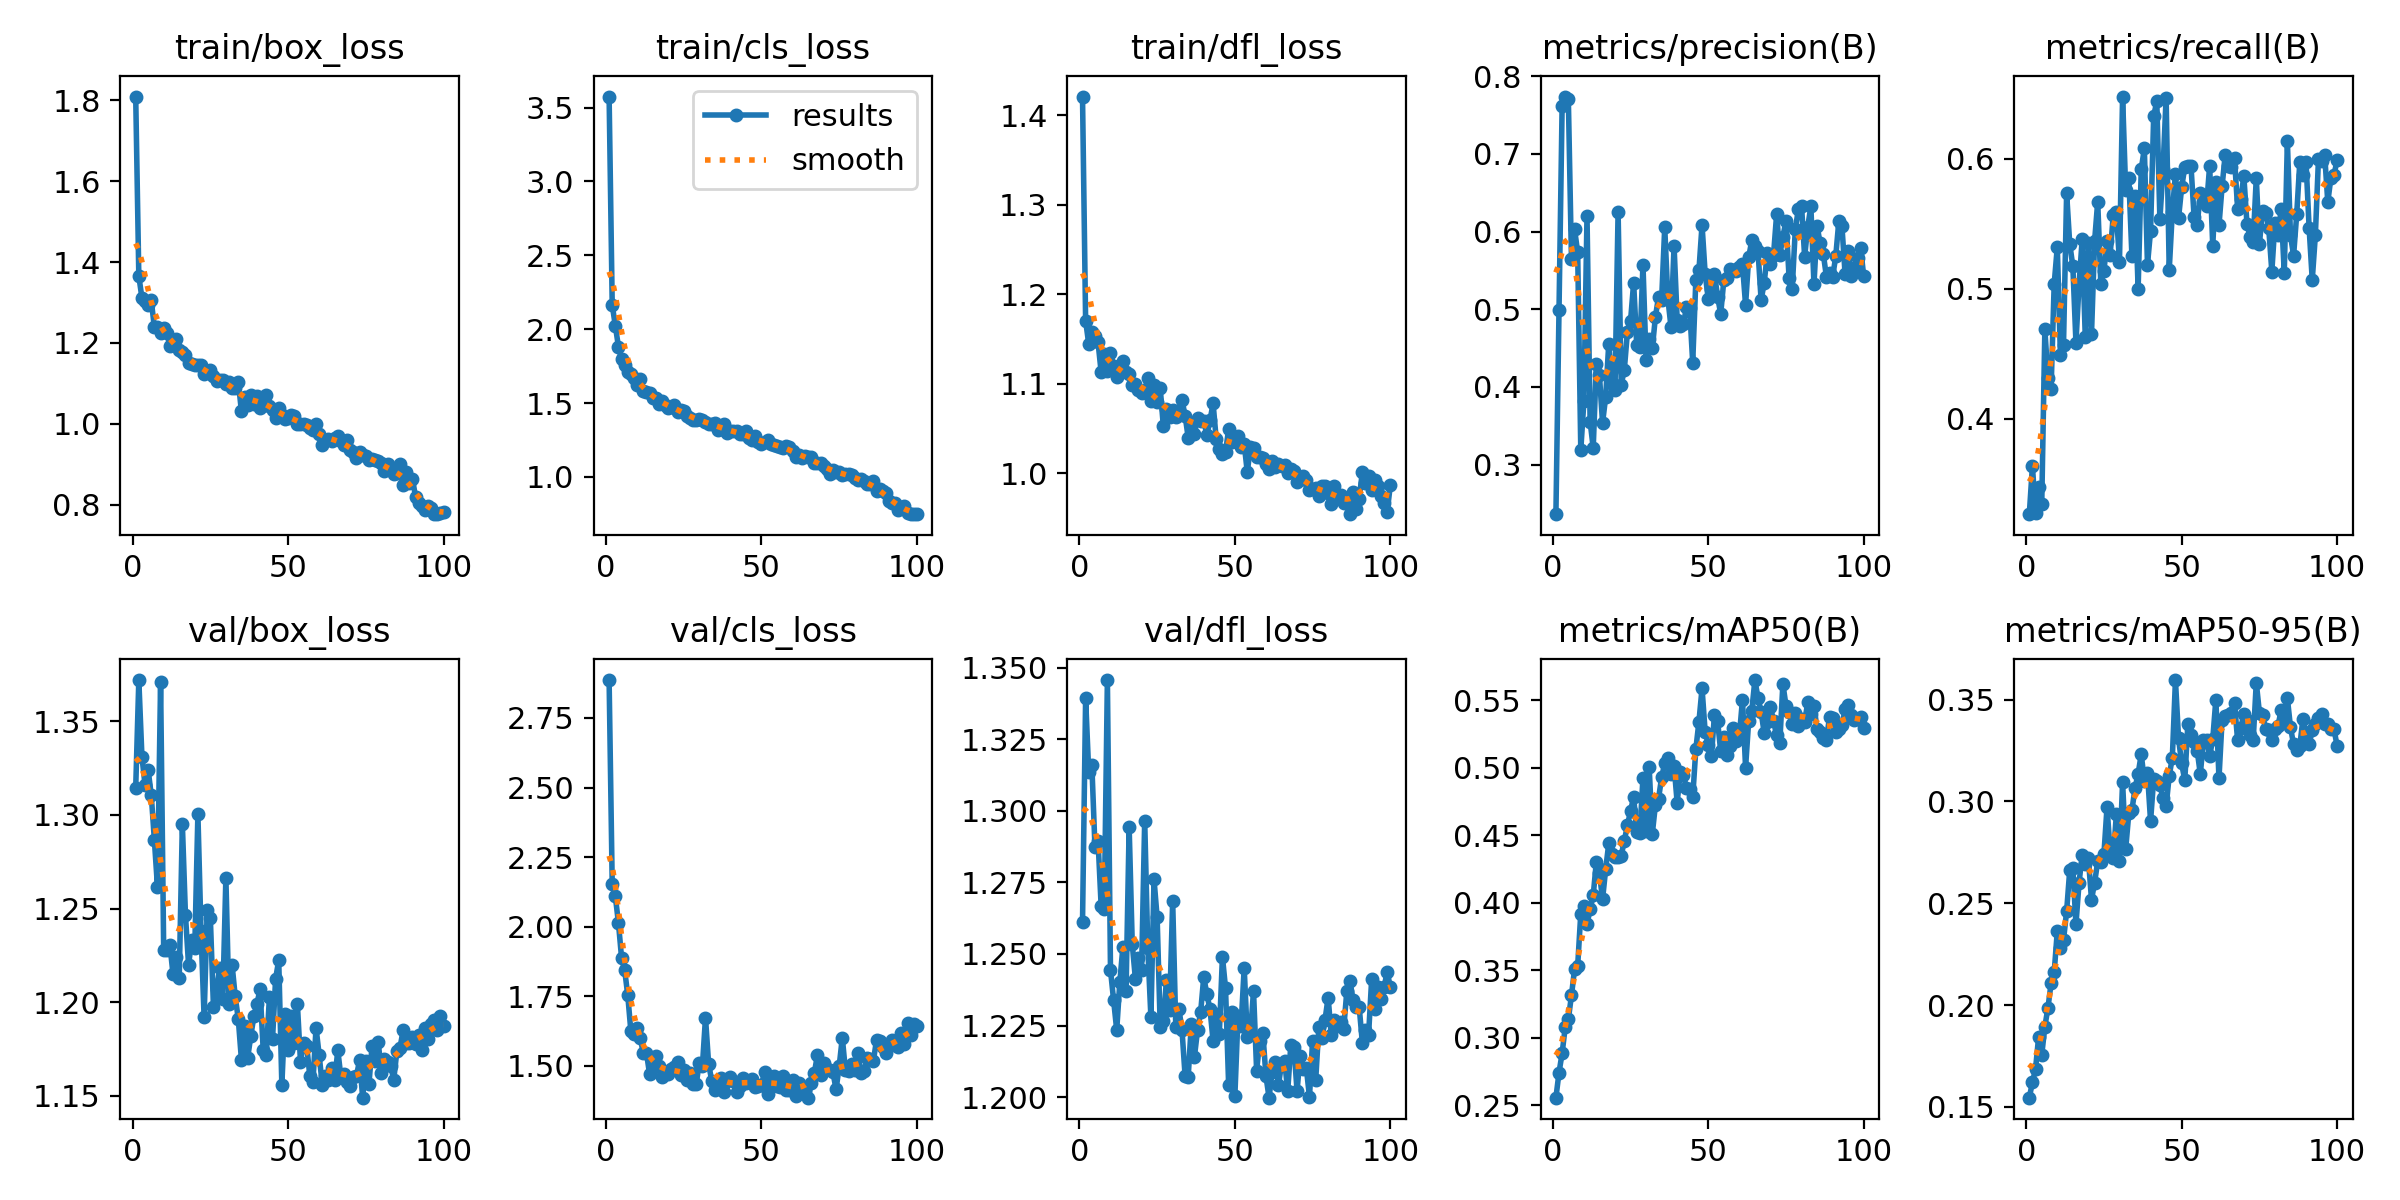

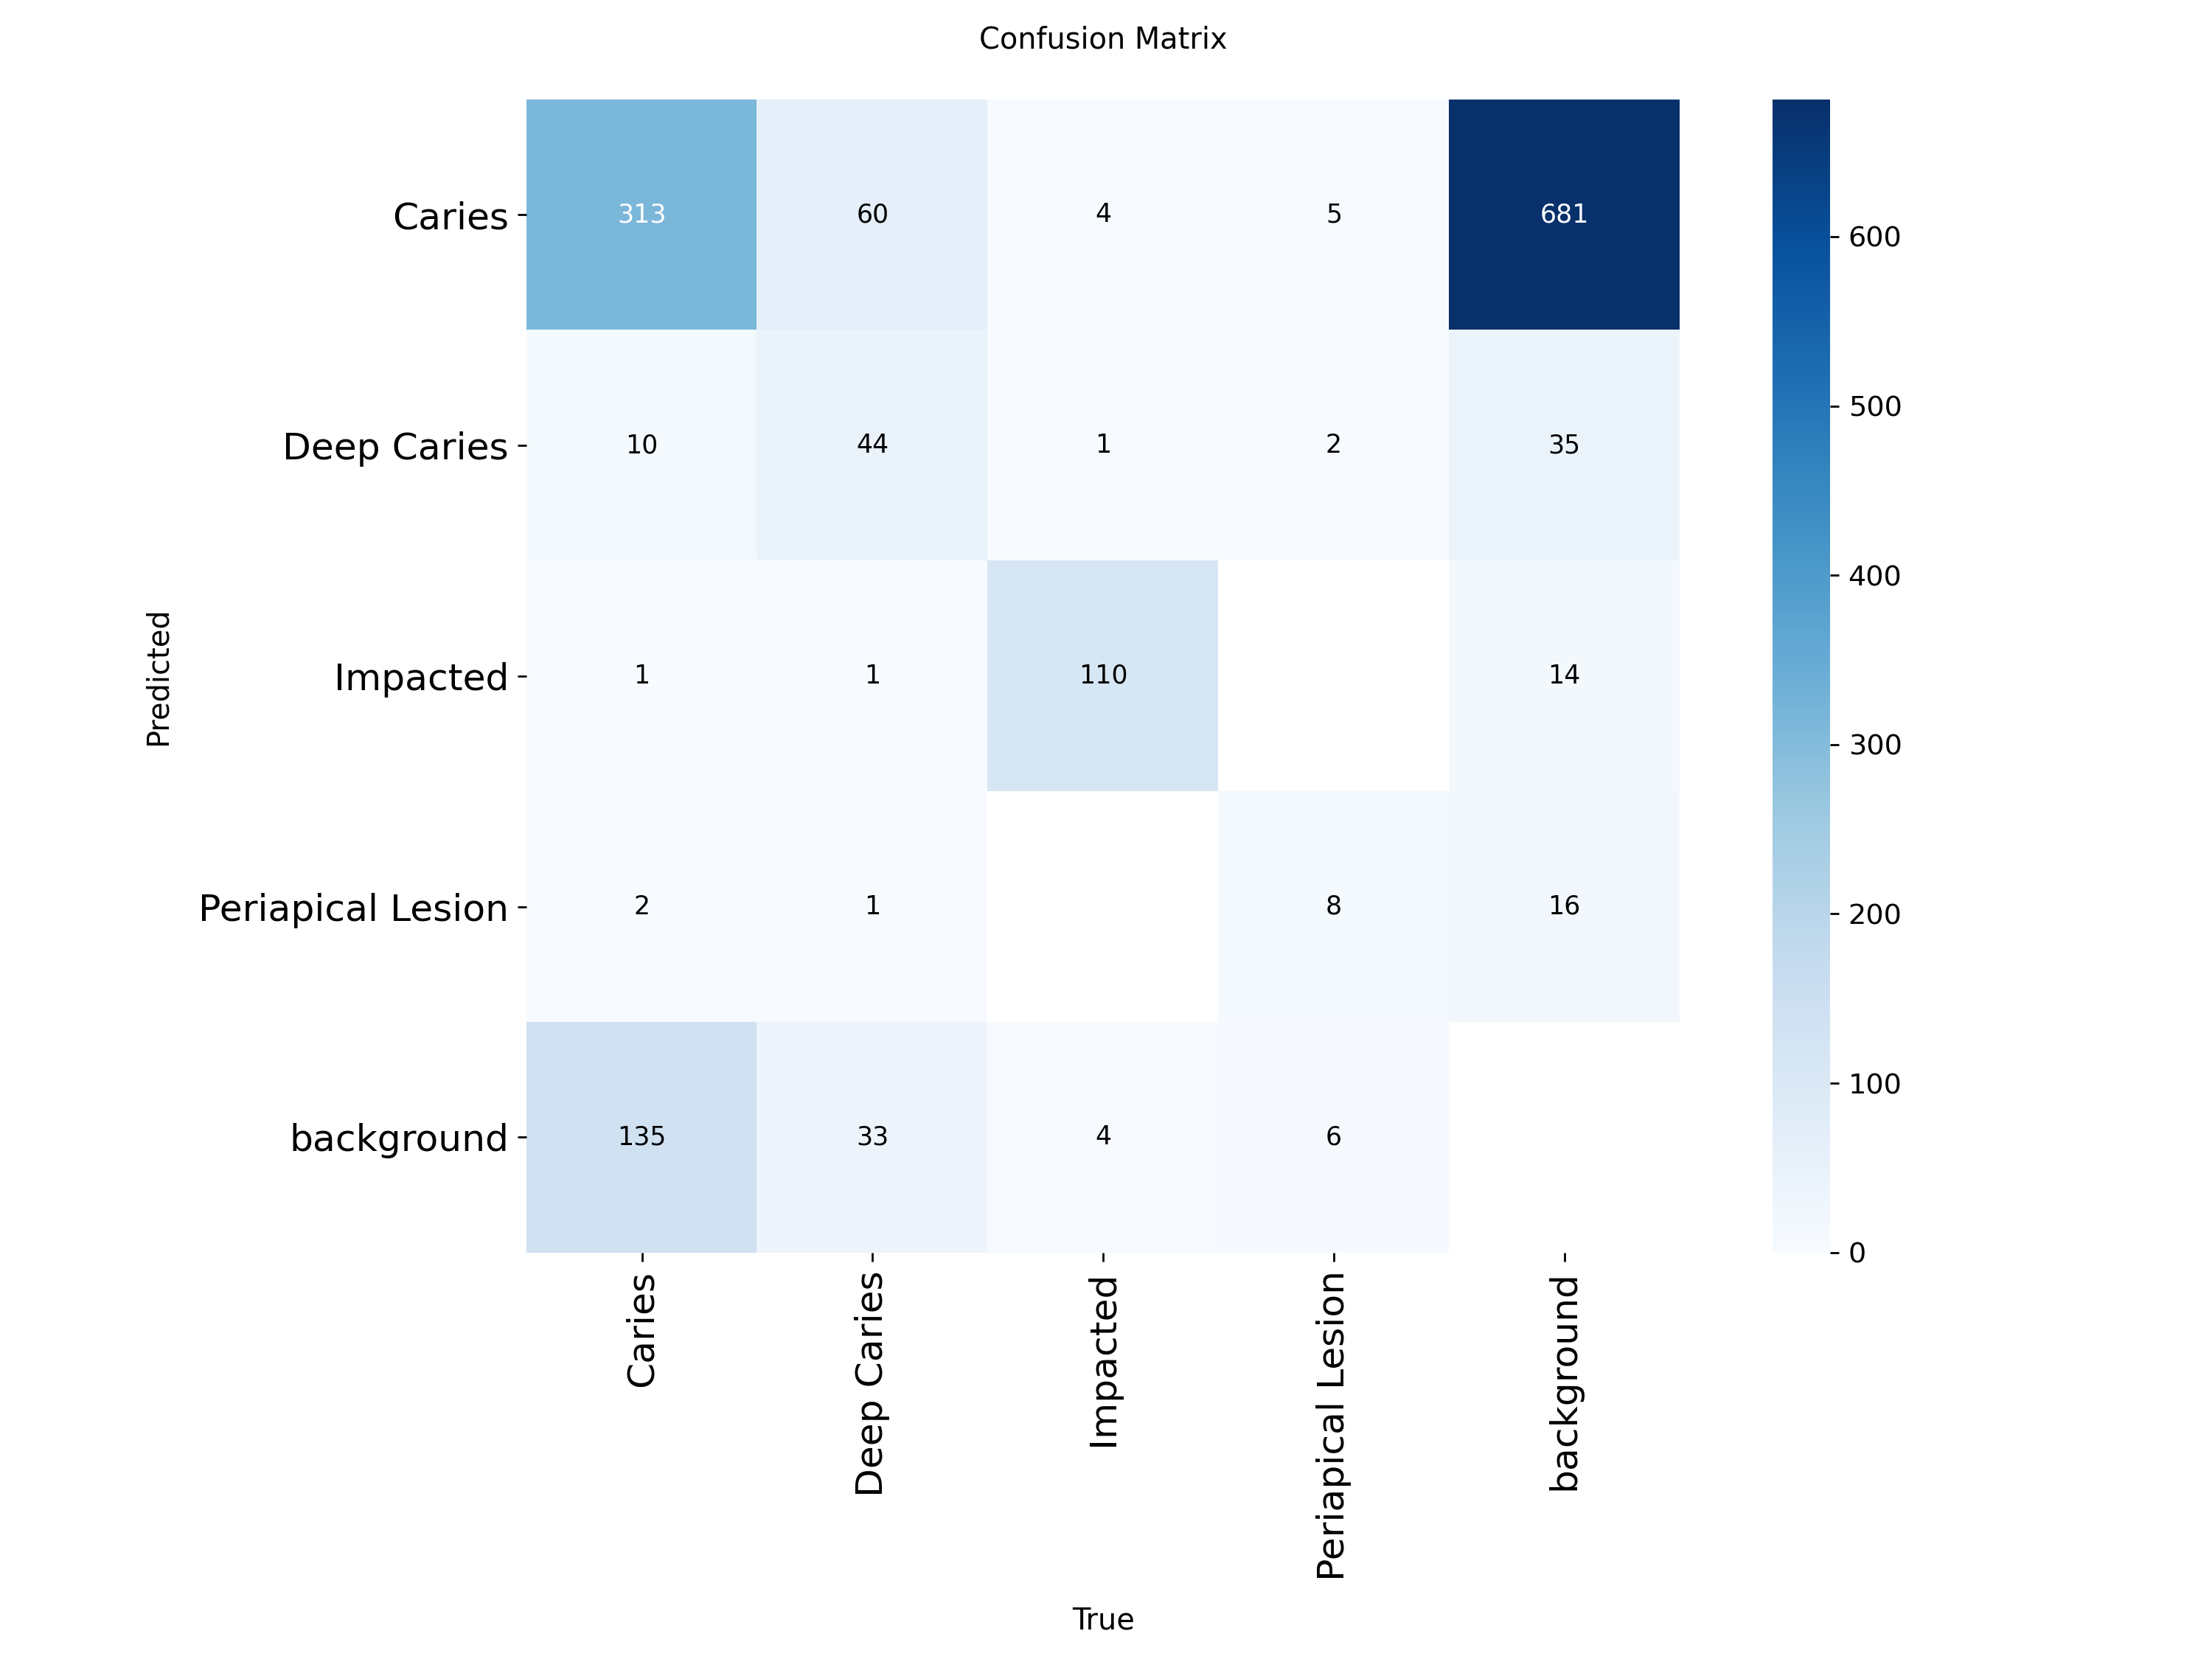

In [6]:
from IPython.display import Image, display

print("Hiển thị kết quả đánh giá mô hình:")

# Biểu đồ đánh giá tổng quan (Loss, mAP)
if os.path.exists('/kaggle/working/runs/detect/train/results.png'):
    display(Image(filename='/kaggle/working/runs/detect/train/results.png', width=1000))
else:
    print("Lỗi: Không tìm thấy tệp results.png")

# Biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
if os.path.exists('/kaggle/working/runs/detect/train/confusion_matrix.png'):
    display(Image(filename='/kaggle/working/runs/detect/train/confusion_matrix.png', width=800))
else:
    print("Lỗi: Không tìm thấy tệp confusion_matrix.png")


Khởi chạy tiến trình kiểm thử và trực quan hóa kết quả...
Phân tích hoàn tất: Tìm thấy 66 ảnh có nhãn trong tổng số 70 ảnh Test.


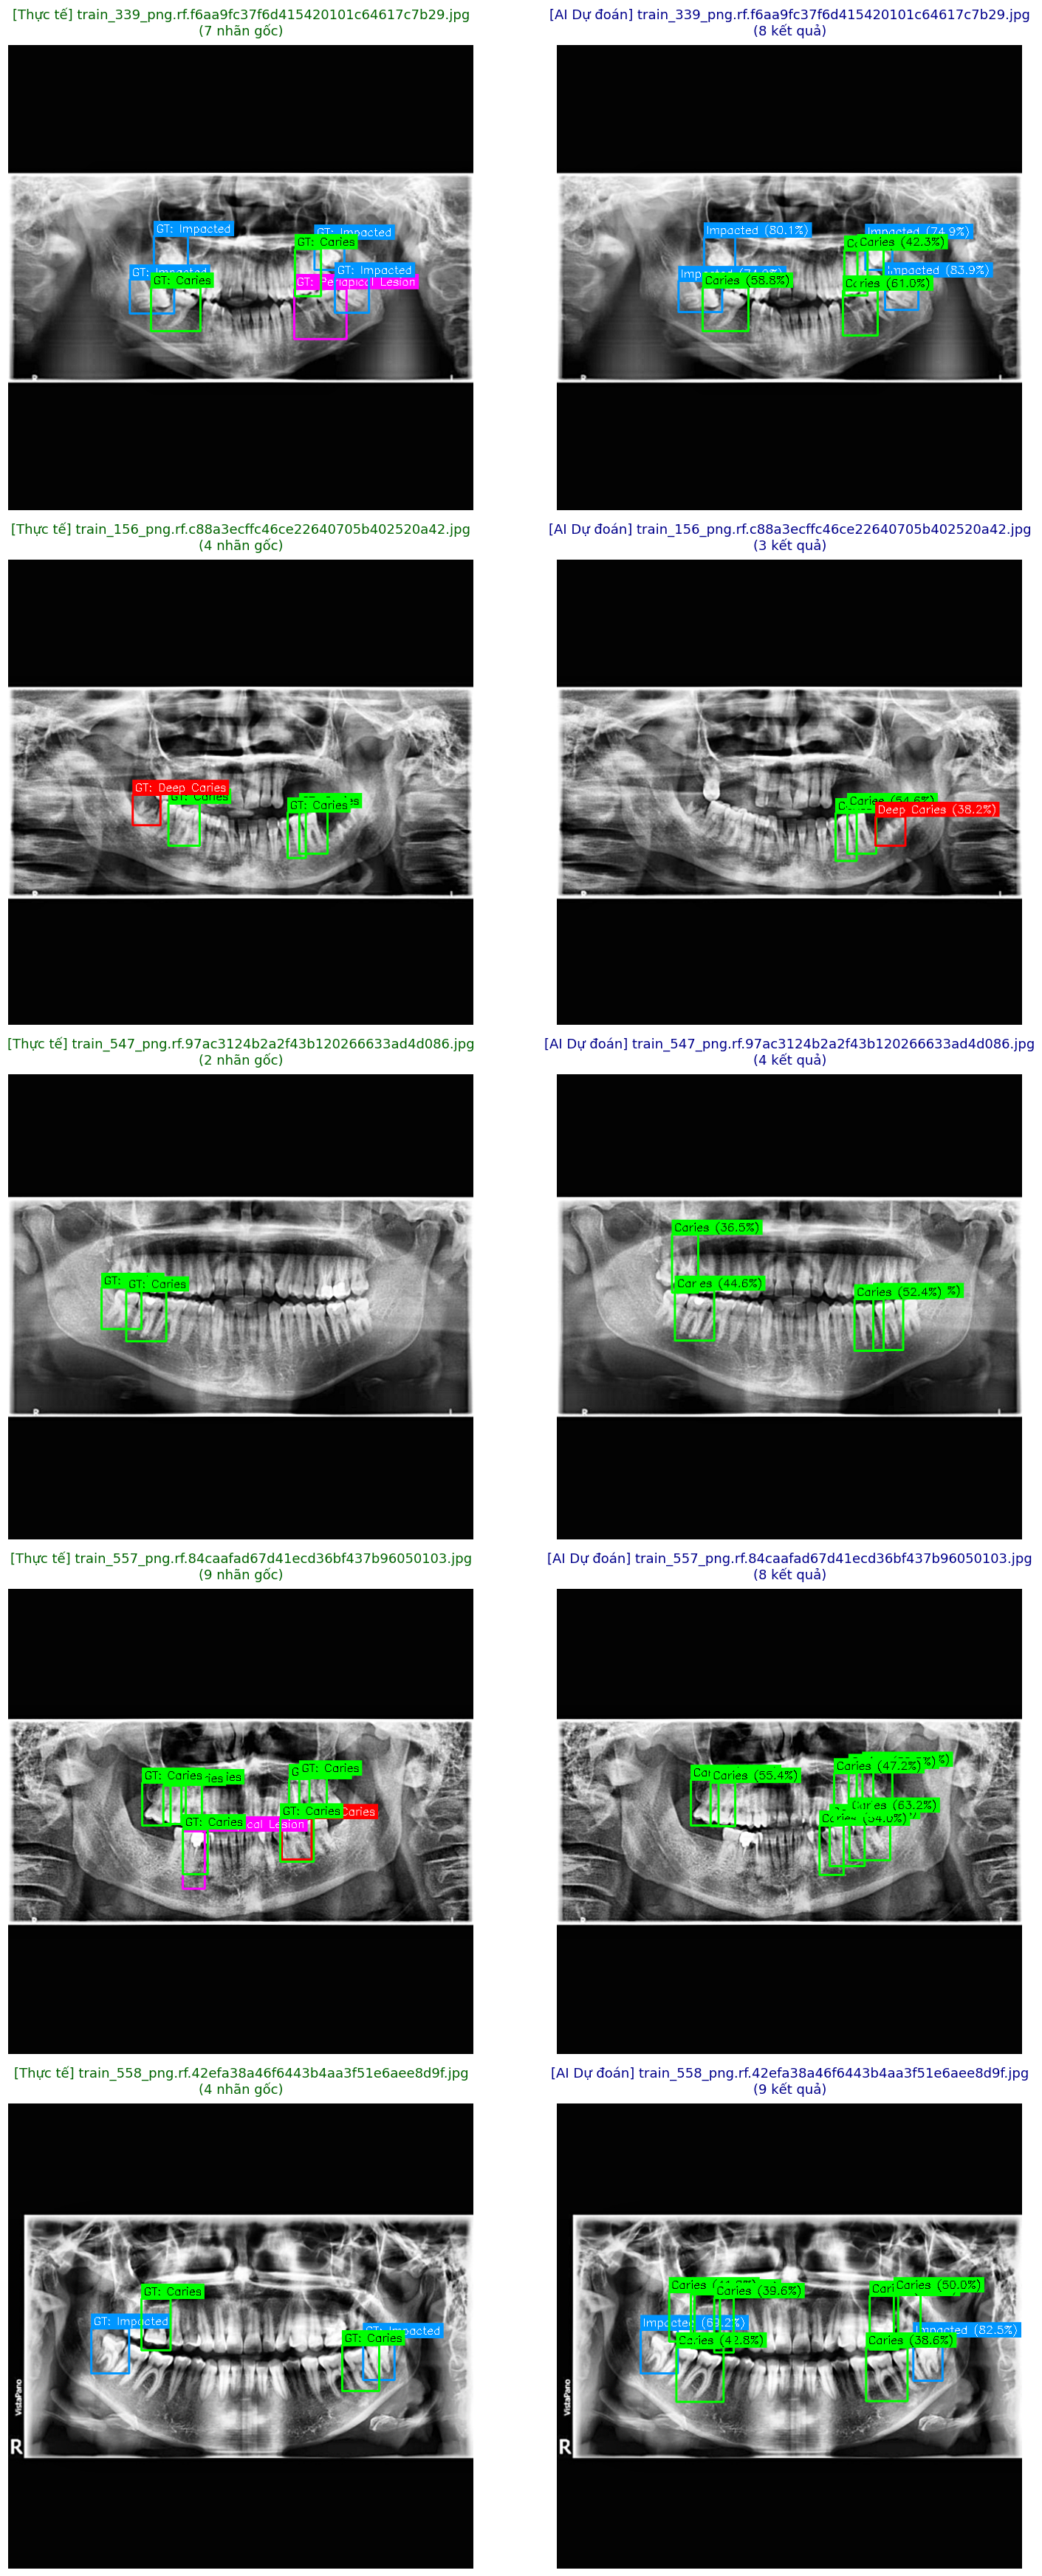

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import os
import random
import glob

print("Khởi chạy tiến trình kiểm thử và trực quan hóa kết quả...")

# 1. Tự động nhận diện đường dẫn (Không dùng đường dẫn cứng)
# dataset_location đã được lưu ở Cell 2
images_dir = os.path.join(dataset_location, 'test', 'images')
labels_dir = os.path.join(dataset_location, 'test', 'labels')
model_path = '/kaggle/working/runs/detect/train/weights/best.pt' # Lấy mô hình vừa train xong

if not os.path.exists(images_dir):
    print(f"Lỗi: Không tìm thấy thư mục Test tại: {images_dir}")
elif not os.path.exists(model_path):
    print(f"Lỗi: Không tìm thấy trọng số mô hình tại: {model_path}. Vui lòng chạy Cell huấn luyện trước.")
else:
    # 2. Khởi tạo mô hình
    model = YOLO(model_path)

    # Định nghĩa mã màu chuẩn đoán (RGB)
    class_colors = {
        0: (0, 255, 0),    # Caries: Xanh lá
        1: (255, 0, 0),    # Deep Caries: Đỏ
        2: (0, 150, 255),  # Impacted: Xanh dương
        3: (255, 0, 255)   # Periapical Lesion: Tím
    }

    def parse_label_line(parts, img_w, img_h):
        """Hàm giải mã tọa độ nhãn (Hỗ trợ cả Bounding Box và Polygon)"""
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        if len(coords) == 4:
            x_c, y_c, w, h = coords
            x1 = int((x_c - w/2) * img_w)
            y1 = int((y_c - h/2) * img_h)
            x2 = int((x_c + w/2) * img_w)
            y2 = int((y_c + h/2) * img_h)
        else:
            xs = [coords[i] * img_w for i in range(0, len(coords), 2)]
            ys = [coords[i] * img_h for i in range(1, len(coords), 2)]
            x1, y1, x2, y2 = int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))
        return cls_id, max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)

    # 3. Quét danh sách ảnh hợp lệ
    all_images = glob.glob(os.path.join(images_dir, '*.*'))
    labeled_images = []
    
    for img_path in all_images:
        file_id = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(labels_dir, f"{file_id}.txt")
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = [l for l in f.readlines() if len(l.strip().split()) >= 5]
            if lines:
                labeled_images.append(img_path)

    print(f"Phân tích hoàn tất: Tìm thấy {len(labeled_images)} ảnh có nhãn trong tổng số {len(all_images)} ảnh Test.")
    
    if len(labeled_images) > 0:
        # Chọn ngẫu nhiên tối đa 5 ảnh
        num_samples = min(5, len(labeled_images))
        selected_images = random.sample(labeled_images, num_samples)
        
        # 4. Vẽ lưới so sánh đối chứng
        fig, axes = plt.subplots(num_samples, 2, figsize=(16, 7 * num_samples))
        if num_samples == 1: axes = np.expand_dims(axes, axis=0) # Khắc phục lỗi nếu chỉ có 1 ảnh

        for idx, img_path in enumerate(selected_images):
            base_name = os.path.basename(img_path)
            file_id = os.path.splitext(base_name)[0]

            img_pil = Image.open(img_path).convert('RGB')
            img_w, img_h = img_pil.size
            img_gt = np.array(img_pil)
            img_pred = np.array(img_pil)

            # --- A. Xây dựng hình ảnh Ground Truth ---
            label_path = os.path.join(labels_dir, f"{file_id}.txt")
            gt_count = 0
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    gt_count += 1
                    cls_id, x1, y1, x2, y2 = parse_label_line(parts, img_w, img_h)
                    color = class_colors.get(cls_id, (255, 255, 0))
                    class_name = model.names.get(cls_id, "Unknown")
                    label_text = f"GT: {class_name}"
                    
                    cv2.rectangle(img_gt, (x1, y1), (x2, y2), color, 2)
                    (tw, _), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                    cv2.rectangle(img_gt, (x1, y1 - 20), (x1 + tw + 6, y1), color, -1)
                    text_color = (0, 0, 0) if cls_id == 0 else (255, 255, 255)
                    cv2.putText(img_gt, label_text, (x1 + 3, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 1)

            # --- B. Xây dựng hình ảnh AI Dự đoán ---
            results = model.predict(source=img_pred, conf=0.35, iou=0.45, verbose=False)
            boxes = results[0].boxes
            pred_count = len(boxes)
            
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])
                cls_id = int(box.cls[0])
                class_name = model.names.get(cls_id, "Unknown")
                color = class_colors.get(cls_id, (255, 255, 0))
                label_text = f"{class_name} ({conf*100:.1f}%)"
                
                cv2.rectangle(img_pred, (x1, y1), (x2, y2), color, 2)
                (tw, _), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img_pred, (x1, y1 - 20), (x1 + tw + 6, y1), color, -1)
                text_color = (0, 0, 0) if cls_id == 0 else (255, 255, 255)
                cv2.putText(img_pred, label_text, (x1 + 3, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 1)

            # --- C. Hiển thị đối chiếu ---
            axes[idx, 0].imshow(img_gt)
            axes[idx, 0].axis('off')
            axes[idx, 0].set_title(f"[Thực tế] {base_name}\n({gt_count} nhãn gốc)", fontsize=13, color='darkgreen', pad=10)

            axes[idx, 1].imshow(img_pred)
            axes[idx, 1].axis('off')
            axes[idx, 1].set_title(f"[AI Dự đoán] {base_name}\n({pred_count} kết quả)", fontsize=13, color='darkblue', pad=10)

        plt.tight_layout()
        plt.show()
